In [1]:
import src.utils as ut
from src.data import load_dataset_and_make_dataloaders
from src.sigma import build_sigma_schedule
from src.common import c_funcs, euler_sample
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
wd = Path("/storage/homefs/ds21n601/diffusion_project_DL/runs/20251211_141713_fashionmnist_cfg")
chkp_path = wd / "checkpoints" / "model_epoch_390.pth"

_, info = load_dataset_and_make_dataloaders(dataset_name="FashionMNIST", root_dir="../data", batch_size=4)
model = ut.build_model_for_sampling(wd / "config.yaml", device, info)
model = ut.load_ckpt_into_model(model, chkp_path, device)

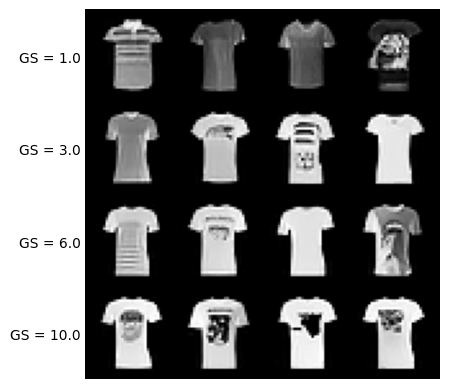

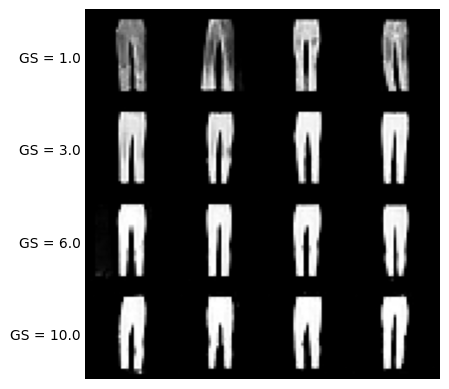

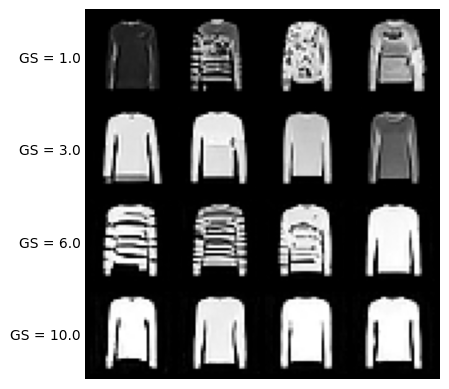

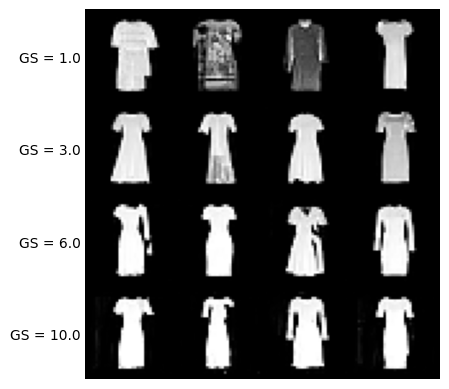

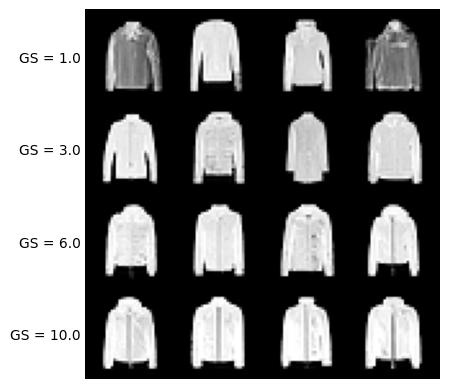

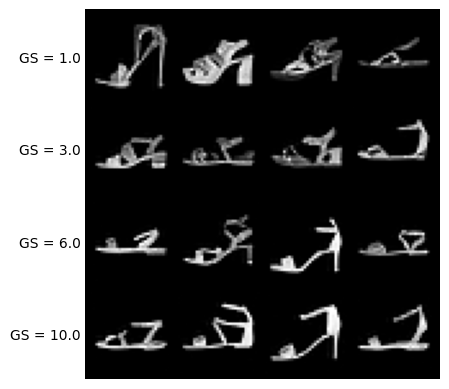

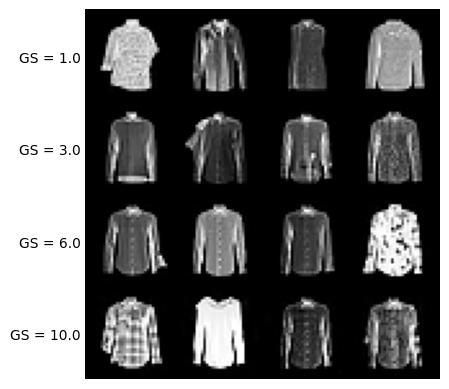

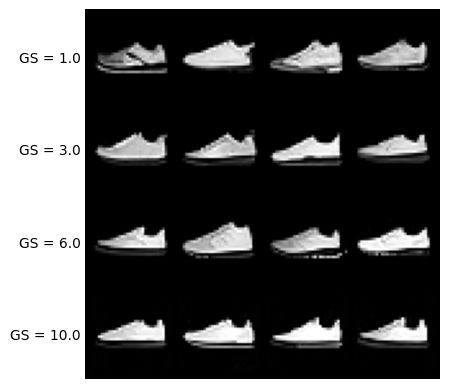

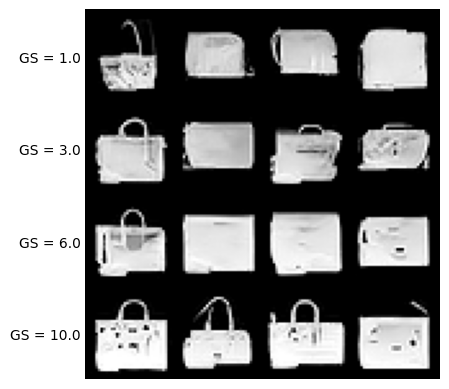

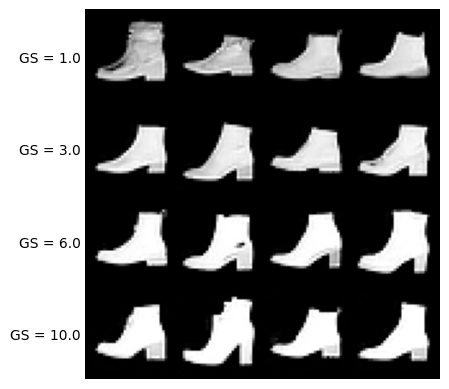

In [19]:
channels = info.image_channels
H = info.image_size
sigma_data = float(info.sigma_data)
n_images = 4
guidance_scales = [1.0, 3.0, 6.0, 10.0]

sigmas = build_sigma_schedule(64)
sigmas = sigmas.to(device)

for class_label in range(info.num_classes):
    grid_imgs = []
    for guidance_scale in guidance_scales:
        samples = euler_sample(model, sigmas, n_images, channels, H, sigma_data, device, class_label=class_label, guidance_scale=guidance_scale)
        imgs = samples.clamp(-1, 1).add(1).div(2)
        grid_imgs.append(make_grid(imgs, nrow=min(8, n_images)).cpu())

    grid_imgs = torch.cat(grid_imgs, axis=1)
    
    fig, ax = plt.subplots()
    ax.imshow(grid_imgs.permute(1, 2, 0))
    
    row_height = grid_imgs.shape[1] // len(guidance_scales)
    yticks = [(i + 0.5) * row_height for i in range(len(guidance_scales))]
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"GS = {gs}" for gs in guidance_scales])

    for spine in ax.spines.values():
        spine.set_visible(False)    
    ax.set_xticks([])
    ax.tick_params(axis='y', length=0)

    plt.show()

In [8]:
wd = Path("/storage/homefs/ds21n601/diffusion_project_DL/runs/20251213_124551_celeba_unet_cfg")

_, info = load_dataset_and_make_dataloaders(dataset_name="CelebA", root_dir="../data", batch_size=4)
chkp = ut.find_latest_checkpoint(wd / "checkpoints")
print(chkp)
model = ut.build_model_for_sampling(wd / "config.yaml", device, info)
model = ut.load_ckpt_into_model(model, chkp, device)

/storage/homefs/ds21n601/diffusion_project_DL/runs/20251213_124551_celeba_unet_cfg/checkpoints/model_epoch_80.pth


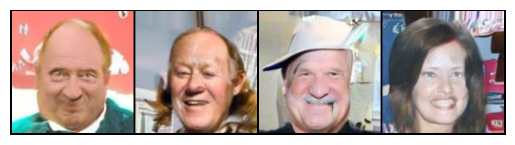

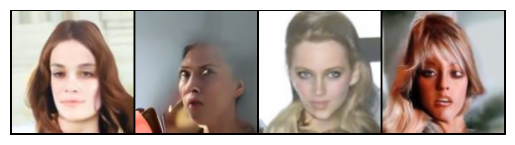

In [12]:
channels = info.image_channels
H = info.image_size
sigma_data = float(info.sigma_data)
n_images = 4
guidance_scale = 3

sigmas = build_sigma_schedule(128)
sigmas = sigmas.to(device)

for class_label in range(info.num_classes):
    samples = euler_sample(model, sigmas, n_images, channels, H, sigma_data, device, class_label=class_label, guidance_scale=guidance_scale)
    imgs = samples.clamp(-1, 1).add(1).div(2)
    grid_img = make_grid(imgs, nrow=min(8, n_images)).cpu()
    plt.imshow(grid_img.permute(1, 2, 0))
    _ = plt.axis("off")
    plt.show()